# Проект: Классификация пользовательских комментариев

## Введение

Интернет-магазин запускает новый сервис, позволяющий пользователям редактировать и дополнять описания товаров, аналогично вики-платформам. Пользователи могут предлагать свои правки и оставлять комментарии к изменениям. Однако среди этих комментариев встречаются токсичные и оскорбительные сообщения, которые могут негативно сказаться на репутации компании и атмосфере общения на платформе.
Чтобы повысить качество взаимодействия пользователей и снизить нагрузку на модераторов, необходимо разработать инструмент, автоматически определяющий токсичные комментарии и отправляющий их на проверку.

## Цель исследования

Целью данного проекта является обучение модели машинного обучения, способной классифицировать пользовательские комментарии на позитивные и негативные. Требуется построить модель, обеспечивающую значение метрики F1 не ниже 0.75.

## Описание данных

В распоряжении имеется датасет **toxic_comments.csv**, содержащий два столбца:
* text — текст пользовательского комментария;
* toxic — целевой признак (1 — комментарий токсичный, 0 — комментарий нейтральный).

Данные включают как нейтральные высказывания, так и комментарии, содержащие оскорбления, угрозы и нецензурную лексику.

## План исследования

* [Загрузка данных](#link1)
* [Предобработка текста](#link2)
* [Анализ данных](#link3)
* [Обучение моделей](#link4)
* [Оценка качества моделей](#link5)
* [Общий вывод](#link6)

## Подготовка рабочего пространства

In [1]:
# установим необходимые библотеки
!pip install phik -q

# импортируем библиотеки
import pandas as pd
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import phik

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# импортируем мой модуль для DS
import ds_lib_tatarnikov as mylib

# игнорируем предупреждения
import warnings
warnings.filterwarnings("ignore")

# настройки отображения таблиц
pd.set_option('display.max_colwidth', 150)

# зададим константы
RANDOM_STATE = 42
TEST_SIZE = 0.10

<a class='anchor' id="link1"></a>
## 1 Загрузка данных

**1.1 Откроем файл с данными**

In [4]:
try:
    df = pd.read_csv('toxic_comments.csv', index_col=[0])
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv', index_col=[0])

df.sort_index(inplace=True)

**1.2 Изучим общую информацию о датафрейме**

In [5]:
mylib.data_overview(df, 'с данными о заказах такси', index_col=True)

,text,toxic
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I ...",0
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits in...",0
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of...",0
4,"You, sir, are my hero. Any chance you remember what page that's on?",0


<class 'pandas.core.frame.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB

Таблица с данными о заказах такси состоит из 159292 строк и 3 столбцов, один из которых используется как индексный.
Пропусков нет.


**Промежуточный итог:**<br>
Данные успешно загружены. Изучена общая информация о предоставленной таблице.
Данным нужна предобработка. В текстах встречаются символы новой строки "\n" и прочие символы разметки, слова, написанные в разных регистрах, аббревиатуры, много пунктуации и, вероятно, многое другое, что необходимо обработать перед началом анализа.

<a class='anchor' id="link2"></a>
## 2 Предобработка данных

**2.1 Создание новых признаков**

Создадим несколько признаков на основе исходного содержания текстов, которые могут содержать информацию о токсичности комментария. 

In [6]:
df['capitals'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['capitals_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))
df['exclamations'] = df['text'].apply(lambda x: x.count('!'))
df['questions'] = df['text'].apply(lambda x: x.count('?'))
df['words'] = df['text'].apply(lambda x: len(x.split()))
df['length'] = df['text'].apply(len)

In [7]:
df.head()

,text,toxic,capitals,capitals_ratio,exclamations,questions,words,length
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I ...",0,17,0.064151,0,1,43,264
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,8,0.070796,1,0,17,112
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits in...",0,4,0.017094,0,0,42,233
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of...",0,11,0.017657,0,0,113,622
4,"You, sir, are my hero. Any chance you remember what page that's on?",0,2,0.029412,0,1,13,67


**2.2 Очистка текста**

Проведем очистку и лемматизацию текста.

In [2]:
# Функция для очистки текста
def clear_text(text):
    # Удаляем всё, кроме латинских букв и пробелов
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Приводим к нижнему регистру
    text = text.lower()
    # Убираем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
# Загружаем необходимые ресурсы NLTK
nltk.download('punkt')                    # токенизация
nltk.download('averaged_perceptron_tagger')  # POS-теги
nltk.download('wordnet')                  # словарь WordNet для лемматизации
nltk.download('omw-1.4')                  # доп. словари для wordnet

# Функция для преобразования POS-тегов NLTK в формат WordNet
def get_wordnet_pos(word):
    """
    Возвращает тег части речи в формате, понятном WordNetLemmatizer.
    Например:
        J* → прилагательное (ADJ)
        V* → глагол (VERB)
        N* → существительное (NOUN)
        R* → наречие (ADV)
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()  # определяем POS-тег первого символа
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)  # если тег неизвестен, считаем словом-существительным

# Инициализация лемматизатора
lemmatizer = WordNetLemmatizer()

# Функция для лемматизации текста
def lemmatize_text(text):
    # токенизация и приведение к нижнему регистру
    words = nltk.word_tokenize(text.lower())  
    # для каждого слова определяем часть речи, лемматизируем с учетом части речи
    lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words]
    # возвращаем строку с объединенными лемматизированными словами
    return " ".join(lemmatized) 

# Проверим работу лемматизатора на примере
example = "The striped bats are hanging on their feet for best"
print(lemmatize_text(example))
# Должно быть: "the strip bat be hang on their foot for best"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


the strip bat be hang on their foot for best


Лемматизация произведена правильно.

Обработаем и лемматизируем всю таблицу с комментариями.

In [12]:
tqdm.pandas()  # включает отображение прогресса
df['text_clean'] = df['text'].apply(clear_text).progress_apply(lemmatize_text)

  0%|          | 0/159292 [00:00<?, ?it/s]

In [13]:
df.head()

,text,toxic,capitals,capitals_ratio,exclamations,questions,words,length,text_clean
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I ...",0,17,0.064151,0,1,43,264,explanation why the edits make under my username hardcore metallica fan be revert they weren t vandalism just closure on some gas after i vote at ...
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,8,0.070796,1,0,17,112,d aww he match this background colour i m seemingly stuck with thanks talk january utc
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits in...",0,4,0.017094,0,0,42,233,hey man i m really not try to edit war it s just that this guy be constantly remove relevant information and talk to me through edits instead of m...
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of...",0,11,0.017657,0,0,113,622,more i can t make any real suggestion on improvement i wonder if the section statistic should be later on or a subsection of type of accident i th...
4,"You, sir, are my hero. Any chance you remember what page that's on?",0,2,0.029412,0,1,13,67,you sir be my hero any chance you remember what page that s on


**Промежуточный итог:**<br>
Созданы новые признаки, которые могут иметь корреляцию с таргетом.<br>
Данные очищены и лемматизированы.

<a class='anchor' id="link3"></a>
## 3 Анализ данных

**3.1 Статистический анализ**

Посмотрим на статистическое описание данных.

In [14]:
df.describe(include='all')

,text,toxic,capitals,capitals_ratio,exclamations,questions,words,length,text_clean
count,159292,159292.000000,159292.000000,159292.000000,159292.000000,159292.000000,159292.000000,159292.000000,159292
unique,159292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157949
top,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,january
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21
mean,NaN,0.101612,17.148620,0.051009,0.661653,0.449043,67.213545,393.691303,NaN
std,NaN,0.302139,96.593201,0.091220,25.921868,1.590390,99.133908,590.111825,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,NaN
25%,NaN,0.000000,3.000000,0.020602,0.000000,0.000000,17.000000,95.000000,NaN
50%,NaN,0.000000,7.000000,0.031579,0.000000,0.000000,36.000000,205.000000,NaN
75%,NaN,0.000000,15.000000,0.048445,0.000000,1.000000,75.000000,435.000000,NaN


Длины комментариев лежат в диапазоне от 5 до 5000 символов. Имеются комментарии в которых количество заглавных букв и восклицательных знаков составляет почти 5000 символов. 

Проверим данные на дисбаланс.

In [15]:
# перевод таблицы с английского на русский
eng_to_rus = {
    'toxic': 'Токсичность', 
    'capitals': 'Количество заглавных букв',
    'capitals_ratio': 'Доля заглавных букв',
    'exclamations': 'Количество восклицательных знаков',
    'questions': 'Количество вопросительных знаков',
    'words': 'Количество слов',
    'length': 'Длина текста'
}

df_rus = df.copy()
df_rus.rename(columns=eng_to_rus, inplace=True)

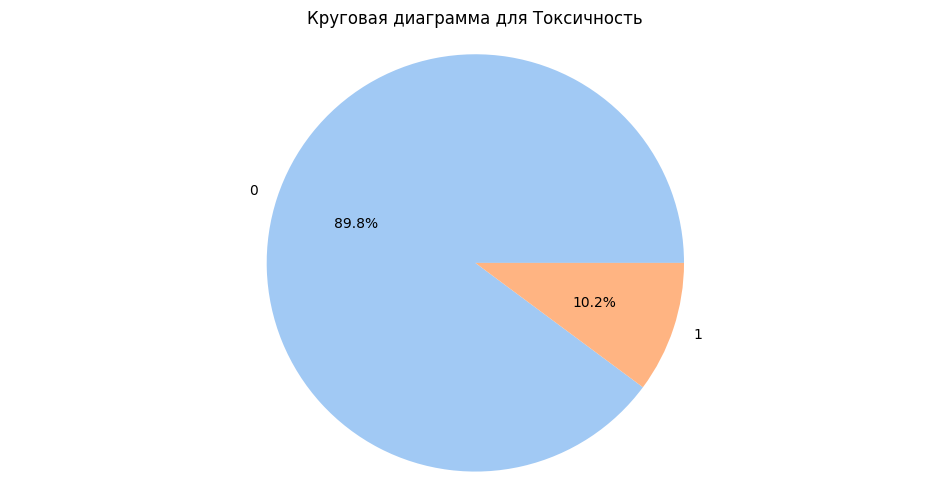

In [16]:
mylib.show_pie(df_rus, 'Токсичность')

Имеется дисбаланс классов. Соотношение токсичных комментариев к нетоксичным примерно 1 к 9.

Посмотрим на разницу в распределении признаков с разбивкой по таргету.

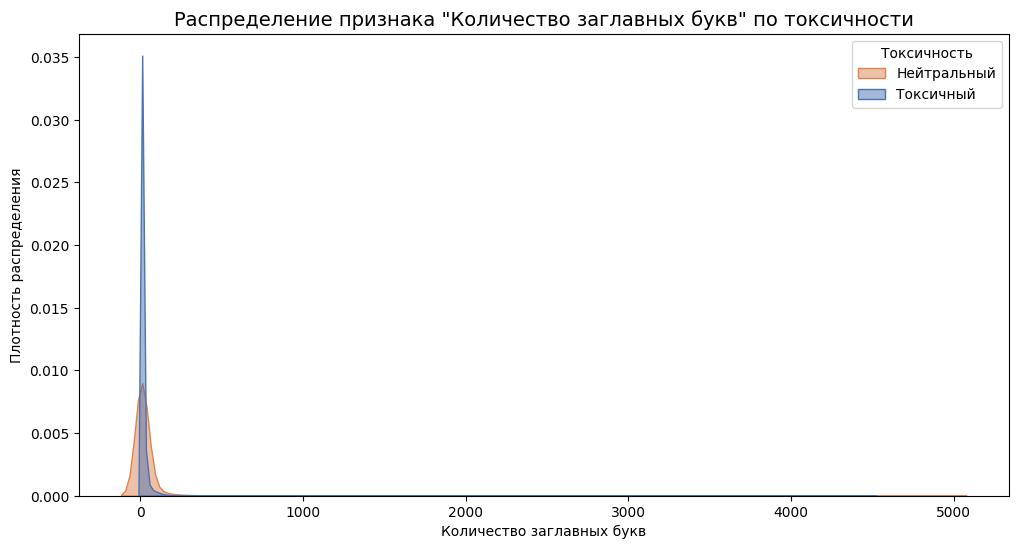

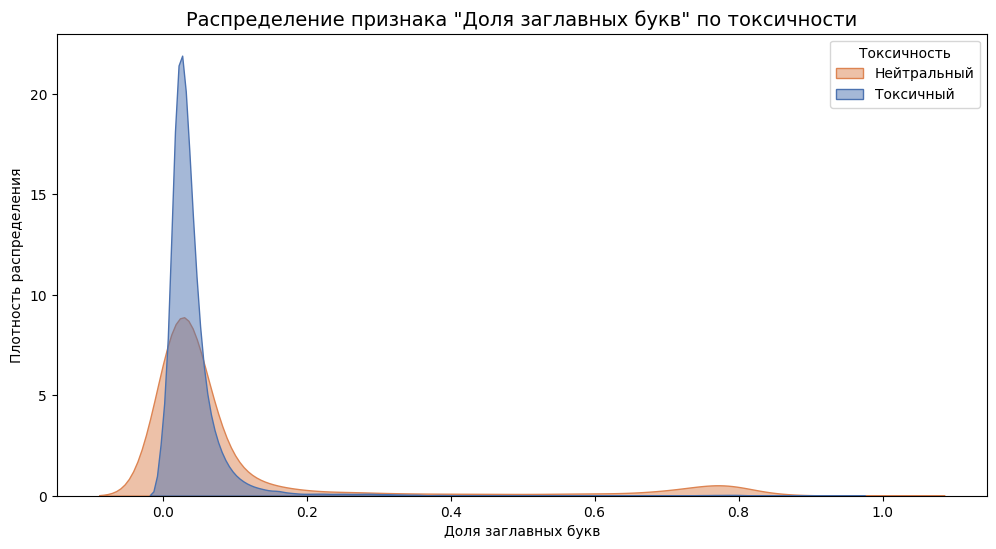

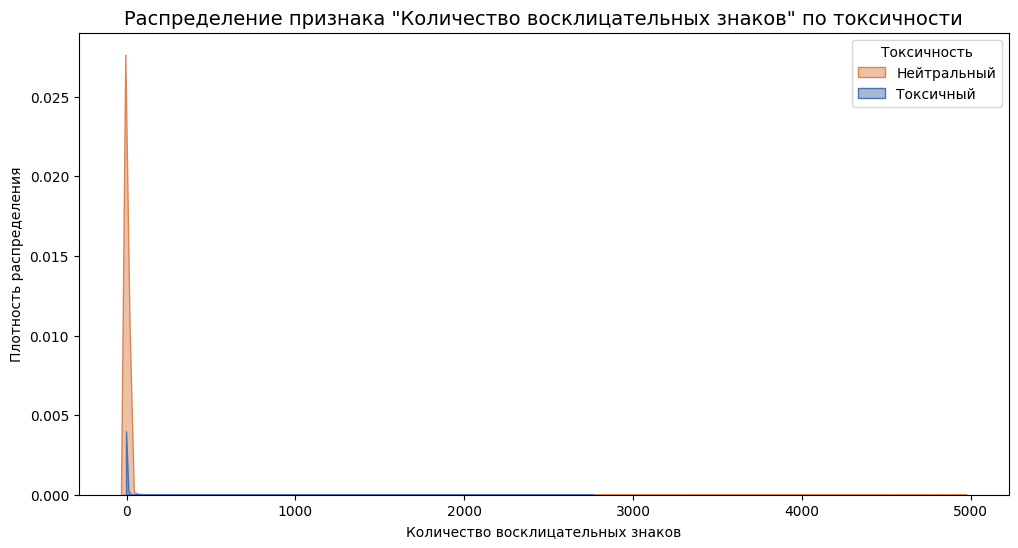

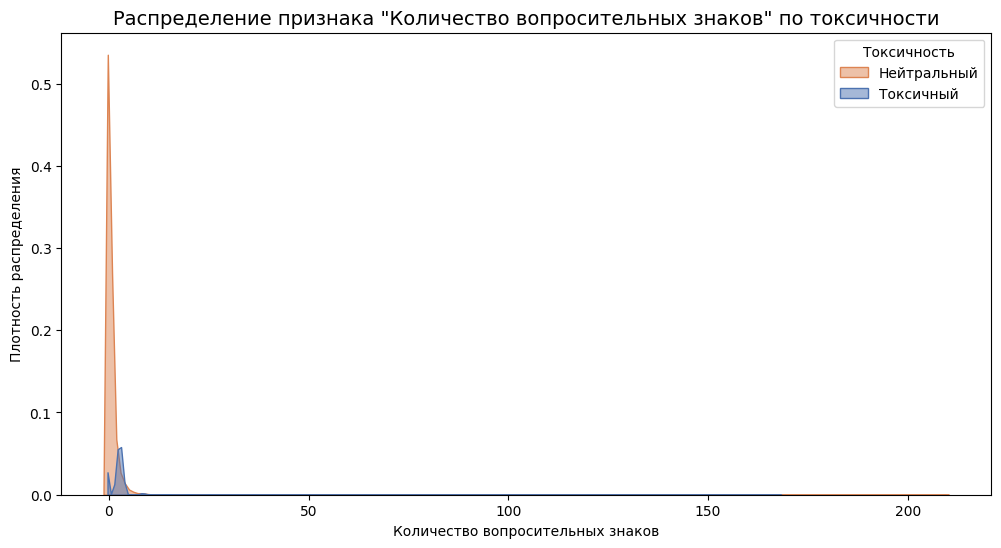

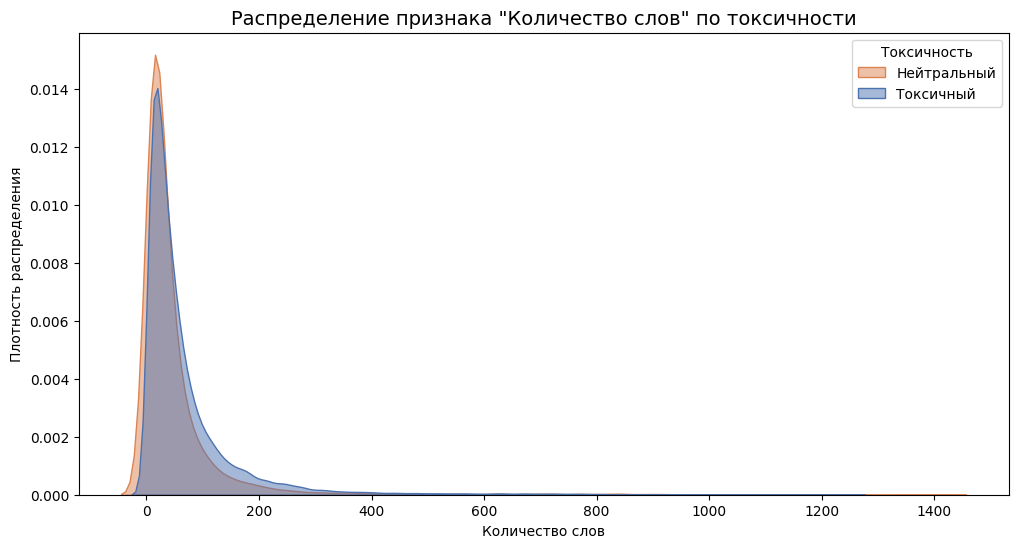

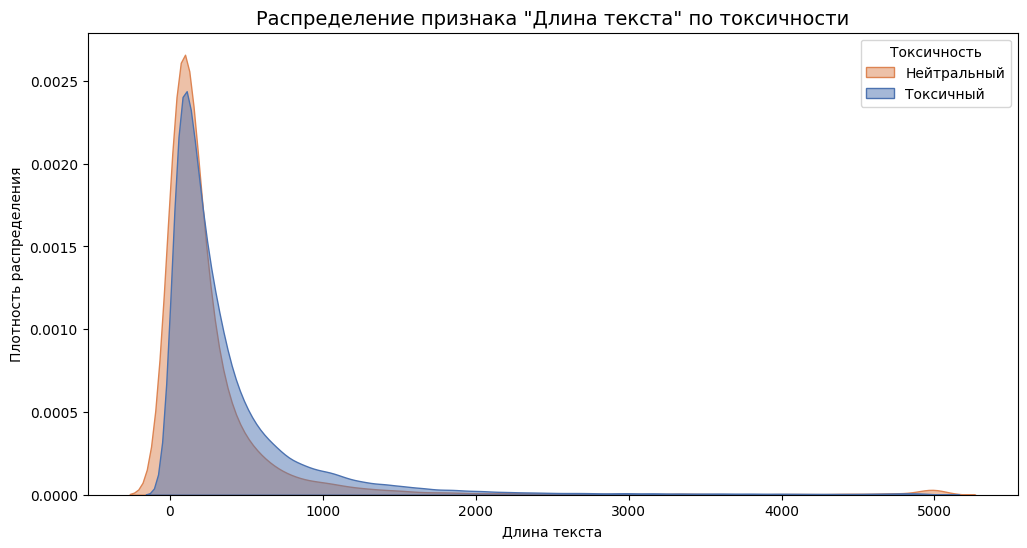

In [17]:
# список признаков
features_rus = [
    'Количество заглавных букв',
    'Доля заглавных букв',
    'Количество восклицательных знаков',
    'Количество вопросительных знаков',
    'Количество слов',
    'Длина текста'
]

for feature in features_rus:
    plt.figure(figsize=(12, 6))
    sns.kdeplot(
        data=df_rus, x=feature, hue='Токсичность', fill=True,
        common_norm=False, palette=['#4C72B0', '#DD8452'], alpha=0.5
    )
    plt.title(f'Распределение признака "{feature}" по токсичности', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Плотность распределения')
    plt.legend(title='Токсичность', labels=['Нейтральный', 'Токсичный'])
    plt.show()


Из графиков видно, что имеется небольшая разница в распределениии данных в зависимости от токсичности текста. Однако графики по большей части пересекаются, и не позволяют однозначно определить целевой признак.

**3.2 Корреляционный анализ**

In [18]:
# Вычисляем матрицу корреляции Phik
corr_matrix_phik = df_rus.drop(columns=['text', 'text_clean']).phik_matrix(interval_cols=features_rus)

# Выводим матрицу
corr_matrix_phik

,Токсичность,Количество заглавных букв,Доля заглавных букв,Количество восклицательных знаков,Количество вопросительных знаков,Количество слов,Длина текста
Токсичность,1.000000,0.116550,0.300201,0.035238,0.022927,0.085956,0.101756
Количество заглавных букв,0.116550,1.000000,0.597543,0.351578,0.334391,0.523691,0.356801
Доля заглавных букв,0.300201,0.597543,1.000000,0.082589,0.081150,0.127905,0.134925
Количество восклицательных знаков,0.035238,0.351578,0.082589,1.000000,0.635891,0.086368,0.129912
Количество вопросительных знаков,0.022927,0.334391,0.081150,0.635891,1.000000,0.187505,0.104659
Количество слов,0.085956,0.523691,0.127905,0.086368,0.187505,1.000000,0.945009
Длина текста,0.101756,0.356801,0.134925,0.129912,0.104659,0.945009,1.000000


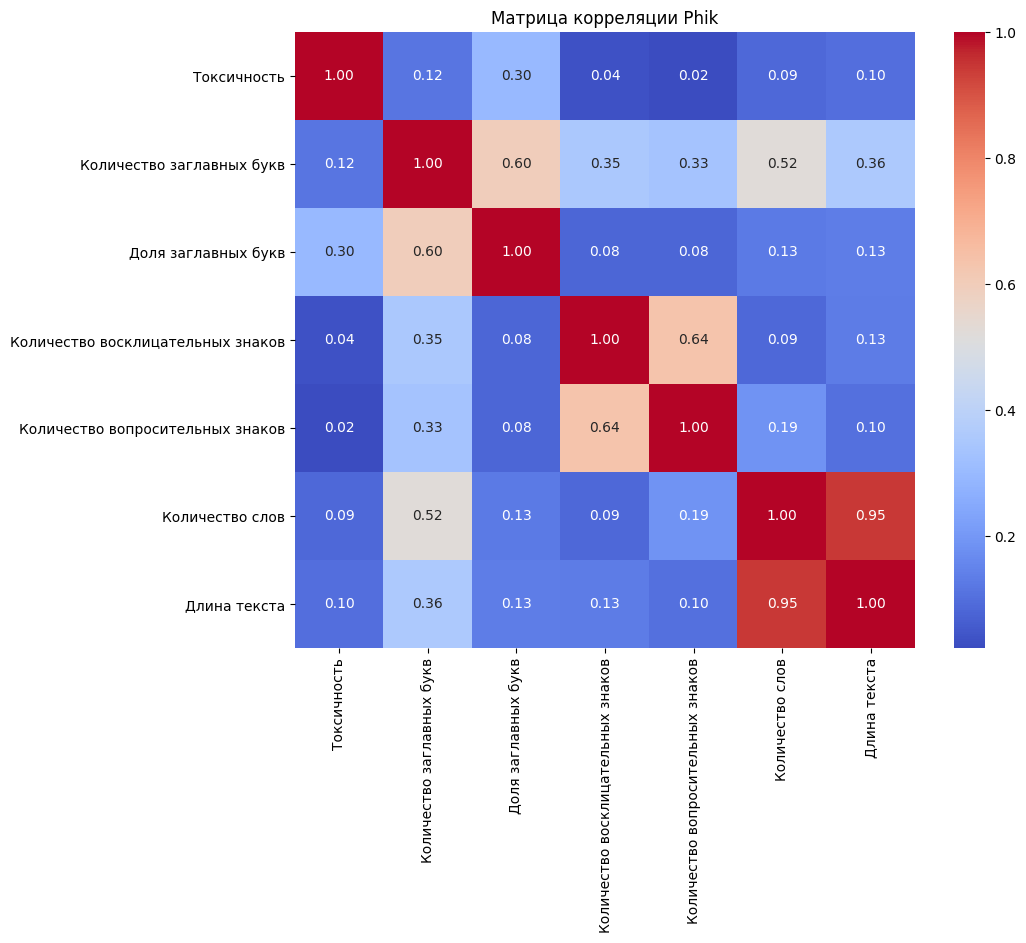

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_phik, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции Phik")
plt.show()

In [20]:
mylib.print_corr_levels(corr_matrix_phik, threshold = 0.1)

[('Весьма высокая корреляция между Длина текста и Количество слов:', 0.945),
 ('Заметная корреляция между Количество вопросительных знаков и Количество восклицательных знаков:',
  0.636),
 ('Заметная корреляция между Доля заглавных букв и Количество заглавных букв:',
  0.598),
 ('Заметная корреляция между Количество заглавных букв и Количество слов:',
  0.524),
 ('Умеренная корреляция между Длина текста и Количество заглавных букв:',
  0.357),
 ('Умеренная корреляция между Количество восклицательных знаков и Количество заглавных букв:',
  0.352),
 ('Умеренная корреляция между Количество вопросительных знаков и Количество заглавных букв:',
  0.334),
 ('Умеренная корреляция между Доля заглавных букв и Токсичность:', 0.3),
 ('Слабая корреляция между Количество вопросительных знаков и Количество слов:',
  0.188),
 ('Слабая корреляция между Длина текста и Доля заглавных букв:', 0.135),
 ('Слабая корреляция между Длина текста и Количество восклицательных знаков:',
  0.13),
 ('Слабая корреляц

**Промежуточный итог:**<br>
Из вновь созданных признаков умеренную корреляцию с таргетом имеет доля заглавных букв. Слабую корреляцию с целевым признаком имеют количество заглавных букв, количество слов и длина текста. Новые признаки могут быть полезны для обучения моделей. 

<a class='anchor' id="link4"></a>
## 4 Обучение моделей

**4.1 Обучение на TF-IDF**

Обучим две модели классификации (LogisticRegression и LGBMClassifier) с подбором гиперпараметров. Для оценки качества моделей будем использовать метрику f1-score.

Разделим данные на тренировочную и тестовую выборки. 

In [21]:
# Разделим данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], 
    df['toxic'], 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['toxic']
)

Для определения тональности комментариев посчитаем TF-IDF для каждого слова. То есть определим как часто определенные слова встречаются в токсичных и нейтральных комментариях.

Сделаем небольшой перебор параметров, потому что обучение идет долго.

In [22]:
models_params = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(
                ngram_range=(1, 1), # только одиночные слова
                stop_words=None,    # уже убрали на этапе очистки
                max_features=50000  # ограничим для ускорения расчетов
            )),
            ('model', LogisticRegression(
                class_weight='balanced',
                solver='liblinear',
                max_iter=1000
            ))
        ]),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l1']
        }
    },

    'LGBMClassifier': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(
                ngram_range=(1, 1), # только одиночные слова
                stop_words=None,    # уже убрали на этапе очистки
                max_features=50000  # ограничим для ускорения расчетов
            )),
            ('model', LGBMClassifier(
                max_depth=-1,
                num_leaves=31,
                device='gpu',
                random_state=RANDOM_STATE
            ))
        ]),
        'params': {
            'model__learning_rate': [0.01, 0.1]
        }
    }
}

In [23]:
best_models = {}

for name, mp in models_params.items():
    print(f"\n🔹 Обучаем {name}...")
    clf = GridSearchCV(
        mp['pipeline'],
        mp['params'],
        scoring='f1',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    clf.fit(X_train, y_train)
    best_models[name] = clf
    print(f"✅ Лучшая метрика F1 для {name}: {clf.best_score_:.3f}")
    print(f"Параметры: {clf.best_params_}\n")


🔹 Обучаем LogisticRegression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
✅ Лучшая метрика F1 для LogisticRegression: 0.756
Параметры: {'model__C': 1, 'model__penalty': 'l1'}


🔹 Обучаем LGBMClassifier...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 14567, number of negative: 128795
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 626550
[LightGBM] [Info] Number of data points in the train set: 143362, number of used features: 10822
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 8 dense feature groups (1.09 MB) transferred to GPU in 0.001730 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.101610 -> initscore=-2.179463
[LightGBM] [Info] Start trainin

Обе модели преодолели требуемый порог метрики F1 > 0,75. 

Лучшей моделью оказалась LGBMClassifier с learning_rate = 0,1. Метрика лучшей модели на кросс-валидации F1 = 0,759.

**4.2 Обучение с учетом числовых признаков**

Попробуем улучшить метрику модели с помощью числовых признаков.

In [24]:
X = df[['text_clean', 'capitals', 'capitals_ratio', 'exclamations', 'questions', 'words', 'length']]
y = df['toxic']

# Разделяем на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            ngram_range=(1, 1),
            stop_words=None,
            max_features=50000
        ), 'text_clean'),
        ('num', StandardScaler(), ['capitals', 'capitals_ratio', 'exclamations', 'questions', 'words', 'length'])
    ]
)

In [26]:
models_params = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(
                class_weight='balanced',
                solver='liblinear',
                max_iter=1000
            ))
        ]),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l1']
        }
    },

    'LGBMClassifier': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', LGBMClassifier(
                max_depth=-1,
                num_leaves=31,
                device='gpu',
                random_state=RANDOM_STATE
            ))
        ]),
        'params': {
            'model__learning_rate': [0.01, 0.1]
        }
    }
}

In [27]:
best_models = {}

for name, mp in models_params.items():
    print(f"\n🔹 Обучаем {name}...")
    clf = GridSearchCV(
        mp['pipeline'],
        mp['params'],
        scoring='f1',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    clf.fit(X_train, y_train)
    best_models[name] = clf
    print(f"✅ Лучшая метрика F1 для {name}: {clf.best_score_:.3f}")
    print(f"Параметры: {clf.best_params_}\n")


🔹 Обучаем LogisticRegression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
✅ Лучшая метрика F1 для LogisticRegression: 0.760
Параметры: {'model__C': 1, 'model__penalty': 'l1'}


🔹 Обучаем LGBMClassifier...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 14567, number of negative: 128795
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 627688
[LightGBM] [Info] Number of data points in the train set: 143362, number of used features: 10828
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (1.64 MB) transferred to GPU in 0.002124 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.101610 -> initscore=-2.179463
[LightGBM] [Info] Start traini

**Промежуточный итог:**<br>
Использование числовых признаков улучшило качество моделей. Обе модели показали хорошие результаты.<br>
Лучшей моделью оказалась LGBMClassifier с learning_rate = 0,1. Метрика лучшей модели на кросс-валидации F1 = 0,767. 

<a class='anchor' id="link5"></a>
## 5 Оценка качества моделей

Посмотрим на метрики лучших моделей на тестовой выборке.

In [28]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"{name}")
    print("F1-score на тестовой выборке:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

LogisticRegression
F1-score на тестовой выборке: 0.7752566180443003
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     14311
           1       0.69      0.89      0.78      1619

    accuracy                           0.95     15930
   macro avg       0.84      0.92      0.87     15930
weighted avg       0.96      0.95      0.95     15930

LGBMClassifier
F1-score на тестовой выборке: 0.7768361581920904
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     14311
           1       0.91      0.68      0.78      1619

    accuracy                           0.96     15930
   macro avg       0.94      0.84      0.88     15930
weighted avg       0.96      0.96      0.96     15930



**Промежуточный итог:**

Проверка качества можедей на тестовой выборке подтвердила результаты, полученные на кросс-валидации.

Обе модели показывают приблизительно одинаковые результаты и выполняют тредование F1 > 0,75.

Точность (precision) предсказаний у LGBMClassifier выше, но полнота (recall) ниже. Это означает, что LGBM делает меньше ложных срабатываний, но пропускает больше токсичных комментариев. LogisticRegression, напротив, обеспечивает лучшее соотношение между полнотой и точностью, что делает её более сбалансированной для решения нашей задачи.

<a class='anchor' id="link6"></a>
## Общий вывод

**Цель исследования** заключалась в создании модели машинного обучения, способной классифицировать комментарии на позитивные и негативные с метрикой F1 не ниже 0.75.

**Проведенные работы**

Данные были предварительно исследованы и очищены. Проведена лемматизация и нормализация текстов: из комментариев удалены спецсимволы, пунктуация и лишние пробелы, все слова приведены к нижнему регистру. Выявлен значительный дисбаланс классов, доля токсичных комментариев составляет около 10%.

Для анализа тональности текстов дополнительно были созданы признаки, отражающие количество и долю заглавных букв, наличие восклицательных и вопросительных знаков, длину текста и число слов. Однако визуализация показала, что распределения по признакам сильно пересекаются. Умеренная корреляция наблюдается только между токсичностью и относительной долей заглавных букв.

Для обучения моделей тексты были векторизированы методом TF-IDF.

Для решения задачи классификации был проведен подбор гиперпараметров двух моделей: LogisticRegression и LGBMClassifier.

**Результаты**

Наилучшие результаты показала модель LGBMClassifier. Метрика F1 на тестовой выборке составила 0.777, что превышает требуемый порог качества.

Однако LogisticRegression с метрикой F1 = 0,775 обеспечивает лучшее равновесие между полнотой и точностью, что делает её оптимальным выбором для поставленной задачи.

Добавление новых числовых признаков, отражающих особенности текста, позволило незначительно повысить метрику F1.

Таким образом, разработанная модель успешно решает задачу определения негативных комментариев, удовлетворяя заданным критериям качества и может быть использована для автоматической модерации пользовательских правок.

**Рекомендации**

1. Оптимизировать пороговое значение классификации. Изменяя порог вероятности отнесения комментария к токсичным, можно регулировать баланс между полнотой (recall) и точностью (precision).

2. Для дальнейшего улучшения качеста моделей можно:
* Использовать более сложные языковые модели
* Увеличить обучающую выборку, особенно по негативным комментариям
  
3. Оценить время предсказания разных моделей. Для работы сервиса может иметь значение не только точность предсказания, но и вычислительные ресурсы, которые будут задействоваться на модерацию каждого комментария.